In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


In [64]:
df_train = pd.read_excel('../../Data/kelulusan_train.xlsx')
df_test = pd.read_excel('../../Data/kelulusan_test.xls')

In [65]:
print(df_train ['JENIS KELAMIN'].unique())
print(df_train ['STATUS MAHASISWA'].unique())
print(df_train ['STATUS NIKAH'].unique())
print(df_train ['STATUS KELULUSAN'].unique())

['PEREMPUAN' 'LAKI - LAKI']
['BEKERJA' 'MAHASISWA']
['BELUM MENIKAH' 'MENIKAH']
['TERLAMBAT' 'TEPAT']


In [66]:
df_train.drop(columns=['STATUS NIKAH'], inplace=True)
df_test.drop(columns=['STATUS NIKAH'], inplace=True)

In [67]:
replacements = {
    'JENIS KELAMIN': {'LAKI - LAKI': 0, 'PEREMPUAN': 1},
    'STATUS MAHASISWA': {'BEKERJA': 0, 'MAHASISWA': 1},
    'STATUS KELULUSAN': {'TERLAMBAT': 0, 'TEPAT': 1}
}
df_train.replace(replacements, inplace=True)
df_test.replace(replacements, inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_94856\759179102.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train.replace(replacements, inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_94856\759179102.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test.replace(replacements, inplace=True)


In [68]:
df_test.isnull().sum()

NAMA                0
JENIS KELAMIN       0
STATUS MAHASISWA    0
UMUR                0
IPS 1               0
IPS 2               0
IPS 3               0
IPS 4               0
IPS 5               0
IPS 6               0
IPS 7               0
IPS 8               4
IPK                 3
STATUS KELULUSAN    0
dtype: int64

In [69]:
df_train.isnull().sum()

NAMA                0
JENIS KELAMIN       0
STATUS MAHASISWA    0
UMUR                0
IPS 1               0
IPS 2               0
IPS 3               0
IPS 4               0
IPS 5               0
IPS 6               0
IPS 7               0
IPS 8               7
IPK                 3
STATUS KELULUSAN    0
dtype: int64

In [70]:
df_train = df_train.dropna()
df_test = df_test.dropna()

In [71]:
df_train = df_train.drop(columns=['NAMA'])
df_test = df_test.drop(columns=['NAMA'])

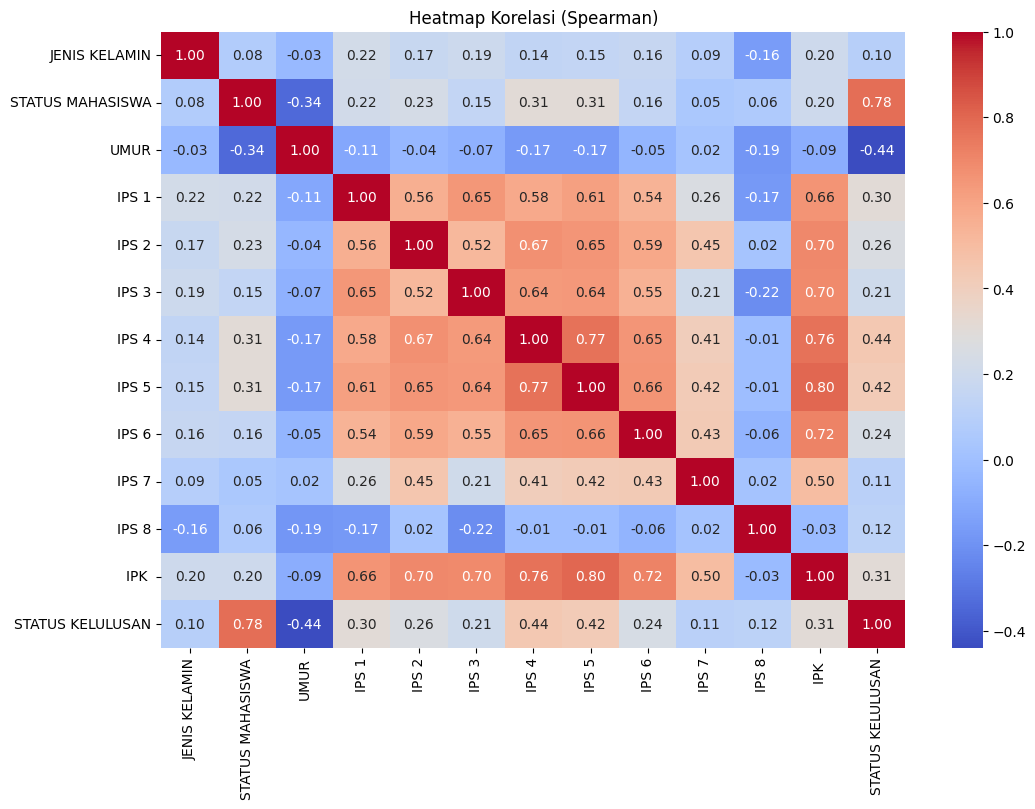

In [72]:
# Menghitung matriks korelasi menggunakan Spearman
correlation_matrix = df_train.corr(method='spearman')
# Membuat heatmap
plt.figure(figsize=(12, 8))
sns.heatmap (correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi (Spearman)")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_94856\2578511420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='STATUS KELULUSAN', data=df_train, palette='Set2')


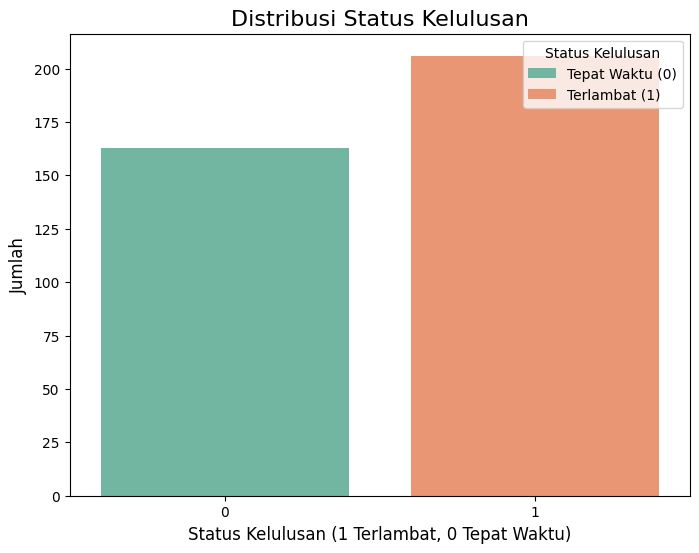

In [73]:
# Membuat diagram batang untuk status kelulusan
plt.figure(figsize=(8, 6))
sns.countplot(x='STATUS KELULUSAN', data=df_train, palette='Set2')
# Menambahkan judul dan label
plt.title('Distribusi Status Kelulusan', fontsize=16)
plt.xlabel('Status Kelulusan (1 Terlambat, 0 Tepat Waktu)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
# Menambahkan legend (adjusted labels for correctness)
plt.legend(title='Status Kelulusan', labels=['Tepat Waktu (0)', 'Terlambat (1)'], loc='upper right')
# Menampilkan plot
plt.show()

In [76]:
# data yang dilatih
from sklearn.discriminant_analysis import StandardScaler


x_train = df_train.drop(columns=['STATUS KELULUSAN'])
y_train = df_train ['STATUS KELULUSAN']
# data validasinya
x_test = df_test.drop(columns=['STATUS KELULUSAN'])
y_test = df_test['STATUS KELULUSAN']
# Normalisasi features after splitting
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())
sm = SMOTE(random_state=42, k_neighbors=1) # Set k_neighbors to 1
x_train_smote, y_train_smote = sm.fit_resample(x_train_scaled, y_train)
print("After SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
STATUS KELULUSAN
1    206
0    163
Name: count, dtype: int64
After SMOTE:
STATUS KELULUSAN
0    206
1    206
Name: count, dtype: int64


In [80]:
param_grid={
'n_neighbors': list(range(1, 31)),
'weights': ['uniform', 'distance'],
'metric': ['euclidean', 'manhattan']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(x_train_smote, y_train_smote)
print("Best Params:", grid.best_params_) 
print("Best Score (CV):", grid.best_score_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'distance'}
Best Score (CV): 0.9029973552747576


In [81]:
best_knn = grid.best_estimator_
best_knn.fit(x_train_smote, y_train_smote)

# prediksi
y_pred = best_knn.predict(x_test_scaled)

In [82]:
print(f"classification_report\n{classification_report(y_test, y_pred)}")

classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00       136

    accuracy                           1.00       138
   macro avg       1.00      1.00      1.00       138
weighted avg       1.00      1.00      1.00       138



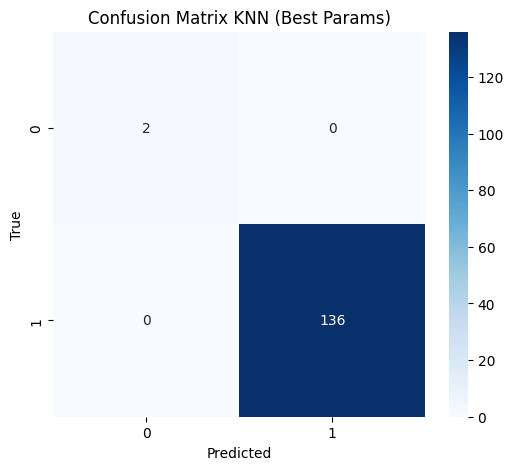

In [83]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [84]:
cv_scores = cross_val_score(best_knn, x_train_smote, y_train_smote, cv = 5 )
print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation Accuracy: 0.9029973552747576
Std Dev: 0.042371318661662674


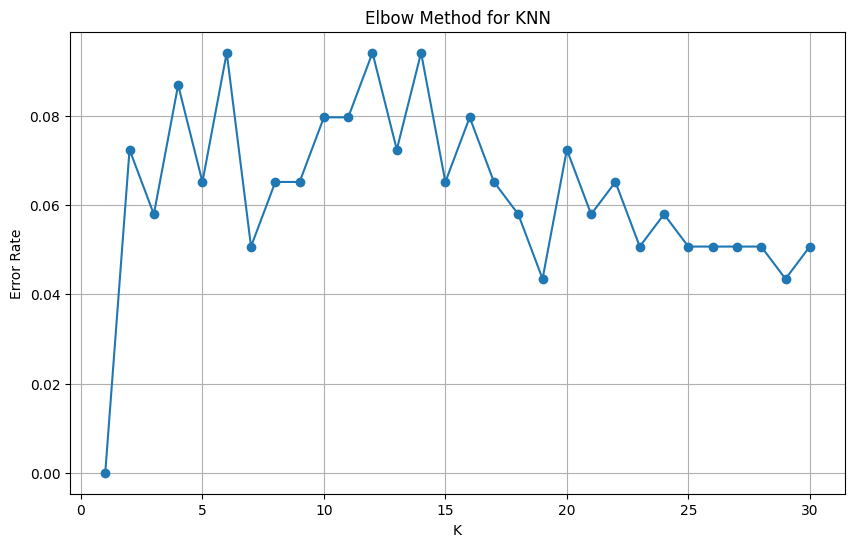

In [ ]:
errors = []
ks = range(1, 31)
y_test_arr = y_test.to_numpy()

for k in ks:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train_smote, y_train_smote)
    pred = knn_temp.predict(x_test_scaled)
    errors.append(np.mean(pred != y_test_arr))

plt.figure(figsize=(10,6))
plt.plot(list(ks), errors, marker='o')
plt.title("Elbow Method for KNN")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()